<a href="https://colab.research.google.com/github/mkg6573/social_media_impact_on_life_ml_/blob/main/Supervised%20Learning%20Algorithms/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Social_media_impact_on_life_Clean_Dataset.csv")
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,Male,Undergraduate,4.0,Facebook,No,6.7,6.8,Neutral
1,23,Female,Undergraduate,1.6,LinkedIn,No,8.6,7.6,Positive
2,22,Male,Graduate,4.6,Instagram,No,6.7,7.0,Neutral
3,18,Male,Undergraduate,7.0,Snapchat,Yes,5.4,5.3,Negative
4,24,Female,High School,7.5,Facebook,Yes,5.0,4.4,Negative


In [3]:
df = df.drop('Mental_Health_Score', axis=1)

In [4]:
df.shape

(1705, 8)

In [5]:
X = df.drop("Overall_Impact", axis=1)
y = df["Overall_Impact"]

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

In [7]:
# Numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

create pipline

In [8]:
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [9]:
cat_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

Preprocessor

In [10]:

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

Split data

In [18]:
from sklearn.preprocessing import LabelEncoder

# Encode target column
le = LabelEncoder()

y = le.fit_transform(y)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Taking diffrent value of parameter values

In [14]:

neighbors_values = [1, 3, 5, 7, 9, 11, 15]
weights_values = ['uniform', 'distance']
metric_values = ['euclidean', 'manhattan']

In [20]:
results = []

# Training loop
for k in neighbors_values:
    for w in weights_values:
        for m in metric_values:

            pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),

                ('model', KNeighborsClassifier(
                    n_neighbors=k,
                    weights=w,
                    metric=m
                ))
            ])

            # Train
            pipeline.fit(X_train, y_train)

            # Predict
            y_pred = pipeline.predict(X_test)

            # Accuracy
            acc = accuracy_score(y_test, y_pred)

            results.append({
                'K': k,
                'Weights': w,
                'Metric': m,
                'Accuracy': acc
            })

# Results dataframe
results_df = pd.DataFrame(results)

# Sort best accuracy
results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(results_df)

     K   Weights     Metric  Accuracy
22  11  distance  euclidean  0.932551
27  15  distance  manhattan  0.926686
6    3  distance  euclidean  0.923754
10   5  distance  euclidean  0.923754
23  11  distance  manhattan  0.923754
18   9  distance  euclidean  0.923754
4    3   uniform  euclidean  0.923754
20  11   uniform  euclidean  0.920821
19   9  distance  manhattan  0.920821
24  15   uniform  euclidean  0.920821
8    5   uniform  euclidean  0.920821
11   5  distance  manhattan  0.917889
16   9   uniform  euclidean  0.917889
26  15  distance  euclidean  0.917889
14   7  distance  euclidean  0.917889
21  11   uniform  manhattan  0.914956
15   7  distance  manhattan  0.912023
17   9   uniform  manhattan  0.912023
12   7   uniform  euclidean  0.912023
0    1   uniform  euclidean  0.909091
25  15   uniform  manhattan  0.909091
2    1  distance  euclidean  0.909091
9    5   uniform  manhattan  0.903226
13   7   uniform  manhattan  0.897361
5    3   uniform  manhattan  0.891496
7    3  dist

KNN with

1. K = 3
2. Weights = distance
3. Metric = euclidean

This model achieved the highest accuracy of 93.26% on your dataset.

In [25]:
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('model', KNeighborsClassifier(
        n_neighbors=3,
        weights='distance',
        metric='euclidean'
    ))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Final Accuracy:", acc)

Final Accuracy: 0.9237536656891495


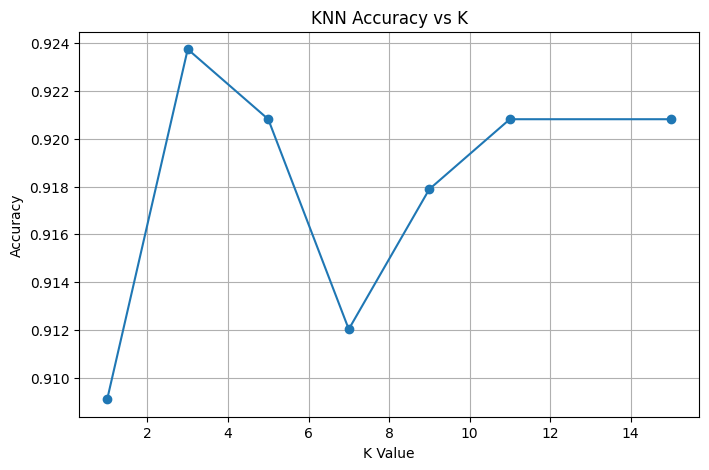

In [27]:
import matplotlib.pyplot as plt

# Filter one combination
graph_data = results_df[
    (results_df['Weights'] == 'uniform') &
    (results_df['Metric'] == 'euclidean')
]

# Sort by K
graph_data = graph_data.sort_values(by='K')

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    graph_data['K'],
    graph_data['Accuracy'],
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.grid(True)

plt.show()